# Sentiment Analysis Using LSTM 

### 1. Problem Statement 
Sentiment Analysis is a key task in Natural Language Processing (NLP) that focuses on 
identifying the emotional tone behind textual data. It is widely used in applications such 
as customer feedback analysis, product reviews, social media monitoring, and opinion 
mining. 
The objective of this project is to build a Sentiment Analysis model using Recurrent 
Neural Networks (RNN) and Deep RNN architectures (LSTM/GRU) to classify text into 
sentiment categories such as Positive, Negative, or Neutral. The model learns 
sequential dependencies in text to improve sentiment prediction accuracy. 

### 2. Data collection

The **IMDb Movie Reviews Dataset** is selected for sentiment analysis. It contains 50,000 movie reviews labeled as positive or negative sentiments. The dataset is divided into training and testing sets and is widely used in NLP tasks for building and evaluating sentiment classification models.

In [27]:
# Data handling
import pandas as pd
import numpy as np

# visulization
import matplotlib.pyplot as plt
import seaborn as sns

# Regular Expressions
import re

# Data Splitting and Label Encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input,Embedding,SimpleRNN,Dense,LSTM,
                                    TimeDistributed,Dropout,BatchNormalization)

# Text Preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
# load Dataset
doc = pd.read_csv("IMDB Dataset.csv")
doc.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
doc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


C:\Users\Ravikant\AppData\Local\Temp\ipykernel_32304\2565623896.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


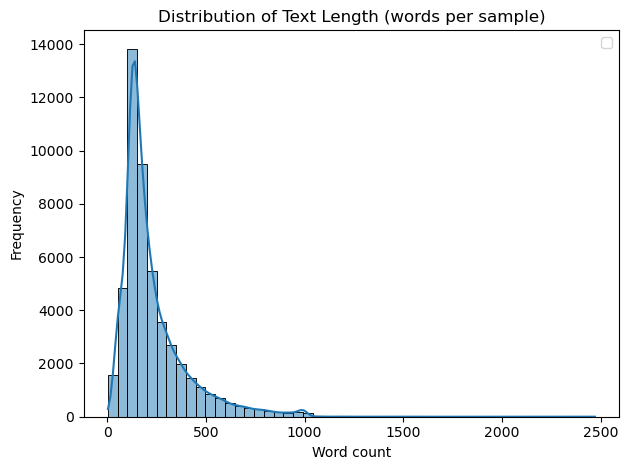

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review, dtype: float64


In [5]:
word_counts = doc["review"].str.split().apply(len)

sns.histplot(word_counts, bins=50, kde=True)
plt.title("Distribution of Text Length (words per sample)")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

print(word_counts.describe())


### 3. Data Preprocessing

#### Text Cleaning

In [7]:
def clean_text(review):
    text = str(review).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # Remove URLs
    text = re.sub(r"@\w+", " ", text)               # Remove mentions
    text = re.sub(r"[^a-z\s]", " ", text)           # Remove numbers, punctuation, emojis, special characters
    text = re.sub(r"\s+", " ", text).strip()        # Remove extra spaces
    return text

# Apply text cleaning
doc["clean_text"] = doc["review"].apply(clean_text)

# Remove empty reviews after cleaning
doc = doc[doc["clean_text"].str.len() > 0]

# Remove duplicate reviews
doc = doc.drop_duplicates(subset="clean_text").reset_index(drop=True)

print("Shape after cleaning & dedup:", doc.shape)

# Display sample cleaned data
doc[["review", "clean_text", "sentiment"]].head()

Shape after cleaning & dedup: (49579, 3)


,review,clean_text,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production br br the filmin...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,positive


### Tokenization

In [8]:
# Tokenization :Splitting sentences into individual words or tokens 
tokenizer = Tokenizer()
tokenizer.fit_on_texts(doc['clean_text'])
print("Words:")
print(tokenizer.word_index)

Words:
{'the': 1, 'and': 2, 'a': 3, 'of': 4, 'to': 5, 'is': 6, 'br': 7, 'it': 8, 'in': 9, 'i': 10, 'this': 11, 'that': 12, 's': 13, 'was': 14, 'as': 15, 'movie': 16, 'for': 17, 'with': 18, 'but': 19, 'film': 20, 'you': 21, 't': 22, 'on': 23, 'not': 24, 'he': 25, 'are': 26, 'his': 27, 'have': 28, 'one': 29, 'be': 30, 'all': 31, 'at': 32, 'they': 33, 'by': 34, 'an': 35, 'who': 36, 'so': 37, 'from': 38, 'like': 39, 'there': 40, 'or': 41, 'just': 42, 'her': 43, 'out': 44, 'about': 45, 'if': 46, 'has': 47, 'what': 48, 'some': 49, 'good': 50, 'can': 51, 'when': 52, 'more': 53, 'very': 54, 'she': 55, 'up': 56, 'no': 57, 'time': 58, 'my': 59, 'even': 60, 'would': 61, 'which': 62, 'only': 63, 'story': 64, 'really': 65, 'see': 66, 'their': 67, 'had': 68, 'me': 69, 'well': 70, 'we': 71, 'were': 72, 'than': 73, 'much': 74, 'bad': 75, 'get': 76, 'been': 77, 'other': 78, 'do': 79, 'people': 80, 'great': 81, 'will': 82, 'also': 83, 'into': 84, 'because': 85, 'how': 86, 'him': 87, 'don': 88, 'first': 

In [9]:
#Convert sentences to number sequences
sequence = tokenizer.texts_to_sequences(doc['review'])
print(sequence[:10])

[[29, 4, 1, 78, 2068, 47, 1047, 12, 101, 150, 42, 3057, 397, 30, 3181, 33, 26, 204, 15, 11, 6, 613, 48, 593, 18, 69, 7, 7, 1, 89, 149, 12, 3211, 69, 45, 3057, 14, 92, 5304, 2, 14750, 136, 4, 561, 62, 266, 9, 204, 38, 1, 646, 142, 1722, 69, 11, 6, 24, 3, 119, 17, 1, 7770, 2315, 41, 11255, 11, 119, 2565, 57, 5800, 18, 5407, 5, 1450, 374, 41, 561, 92, 6, 3785, 9, 1, 355, 358, 4, 1, 646, 7, 7, 8, 6, 433, 3057, 15, 12, 6, 1, 11412, 357, 5, 1, 14751, 6706, 2501, 1040, 50086, 8, 2692, 1407, 23, 22568, 518, 35, 4590, 2455, 4, 1, 1180, 116, 31, 1, 6940, 28, 2882, 11724, 2, 387, 50087, 37, 16244, 6, 24, 298, 23, 1, 4831, 2866, 518, 6, 341, 5, 108, 24279, 8021, 39142, 14752, 4970, 7649, 2418, 2, 53, 37, 43529, 325, 9039, 7245, 12608, 2, 8544, 31154, 26, 113, 224, 241, 7, 7, 10, 61, 133, 1, 283, 1324, 4, 1, 119, 6, 680, 5, 1, 193, 12, 8, 267, 116, 78, 276, 2993, 819, 184, 1291, 4106, 17, 2462, 1216, 819, 1424, 819, 866, 3057, 940, 185, 1, 89, 397, 10, 124, 210, 3211, 69, 15, 37, 1604, 8, 14, 2227,

### Padding Sequences

In [10]:
# Padding Sequences: Ensuring equal input length by padding or truncating sequences
pad_seq = pad_sequences(sequence)
print(pad_seq)

[[    0     0     0 ...   127  4049   480]
 [    0     0     0 ...  1966    70   221]
 [    0     0     0 ...    66    18   349]
 ...
 [    0     0     0 ... 21915     2  5873]
 [    0     0     0 ...    51   729    45]
 [    0     0     0 ...   790    11    16]]


In [11]:
# Feature (input)
X = pad_seq                         
X

array([[    0,     0,     0, ...,   127,  4049,   480],
       [    0,     0,     0, ...,  1966,    70,   221],
       [    0,     0,     0, ...,    66,    18,   349],
       ...,
       [    0,     0,     0, ..., 21915,     2,  5873],
       [    0,     0,     0, ...,    51,   729,    45],
       [    0,     0,     0, ...,   790,    11,    16]],
      shape=(49579, 2444), dtype=int32)

In [12]:
# label Encoding Target column
le = LabelEncoder()
y = le.fit_transform(doc[['sentiment']])
print("Encoded classes",le.classes_)

Encoded classes ['negative' 'positive']


C:\Users\Ravikant\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# 4. Model Building 

In [13]:
# Train Test split 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(39663, 2444)
(9916, 2444)
(39663,)
(9916,)


In [14]:
# vocab is the unique words in sentences.
vocab_size = len(tokenizer.word_index)+1
vocab_size

99282

In [15]:
# Model Architecture
model = Sequential()
# Input layer
model.add(Input(shape=(X_train.shape[1],)))
# Embedding Layer
model.add(Embedding(input_dim=vocab_size,output_dim=64))
model.add(Dropout(0.2))

# Simple LSTM Layer
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='sigmoid'))


In [16]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 2444, 64)            │       6,354,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2444, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,366,497 (24.29 MB)

 Trainable params: 6,366,497 (24.29 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Compiling the LSTM Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [18]:
# Model Training and Validation
history = model.fit(X_train, y_train, verbose=1, validation_split=0.2,batch_size=128, epochs =10)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 662s 3s/step - accuracy: 0.7691 - loss: 0.4739 - val_accuracy: 0.8571 - val_loss: 0.3699
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 661s 3s/step - accuracy: 0.9004 - loss: 0.2608 - val_accuracy: 0.8775 - val_loss: 0.3047
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 603s 2s/step - accuracy: 0.9467 - loss: 0.1542 - val_accuracy: 0.8873 - val_loss: 0.3193
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 665s 3s/step - accuracy: 0.9669 - loss: 0.1002 - val_accuracy: 0.8835 - val_loss: 0.3675
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 662s 3s/step - accuracy: 0.9812 - loss: 0.0629 - val_accuracy: 0.8748 - val_loss: 0.4050
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 710s 3s/step - accuracy: 0.9833 - loss: 0.0532 - val_accuracy: 0.8724 - val_loss: 0.4928
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 666s 3s/step - accuracy: 0.9876 - loss: 0.0410 - val_accuracy: 0.8455 - val_loss: 0.4775
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 683s 3s/step - accuracy: 0.9892 - loss: 0.0376 - val_accu

# Model Evaluation

#### Evaluate Model Accuracy and Loss

In [19]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

310/310 ━━━━━━━━━━━━━━━━━━━━ 77s 247ms/step - accuracy: 0.8528 - loss: 0.5620 
Test Loss: 0.5620251297950745
Test Accuracy: 0.8527632355690002


#### Loss and Accuracy Analysis (Training vs Validation)

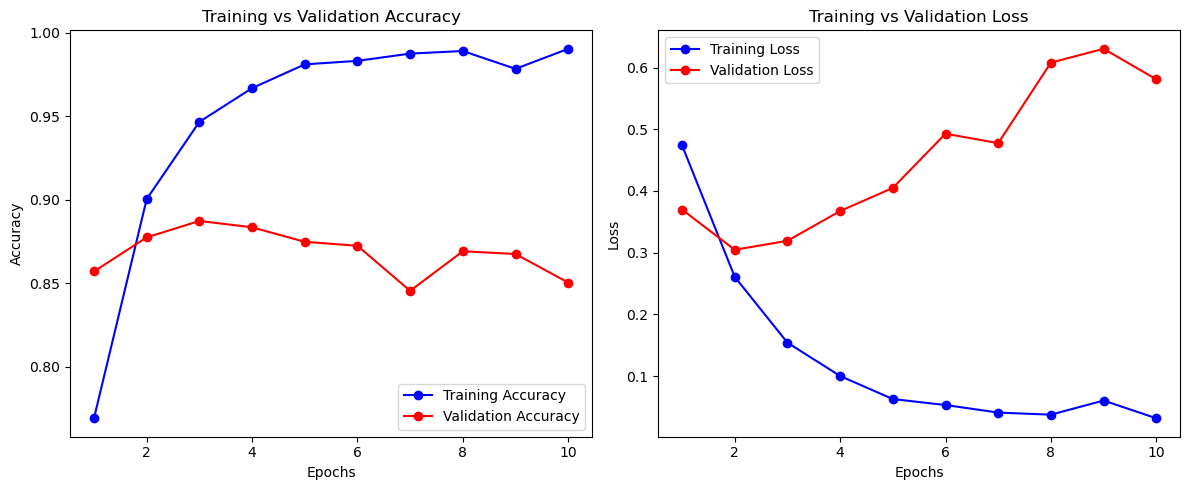

In [20]:
# Training and Validation Performance Visualization
acc = history.history['accuracy']
loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

# Number of epochs
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
# Model Evaluation
y_prob = model.predict(X_test).ravel()   # predicted probability of cancellation
y_pred = (y_prob >= 0.5).astype(int)        # convert probability to class label

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Positive', 'Negative']))

310/310 ━━━━━━━━━━━━━━━━━━━━ 77s 246ms/step 
Test Accuracy : 0.8528
Test ROC-AUC  : 0.9323

              precision    recall  f1-score   support

    Positive       0.91      0.78      0.84      4945
    Negative       0.81      0.93      0.86      4971

    accuracy                           0.85      9916
   macro avg       0.86      0.85      0.85      9916
weighted avg       0.86      0.85      0.85      9916



#### Confusion Matrix

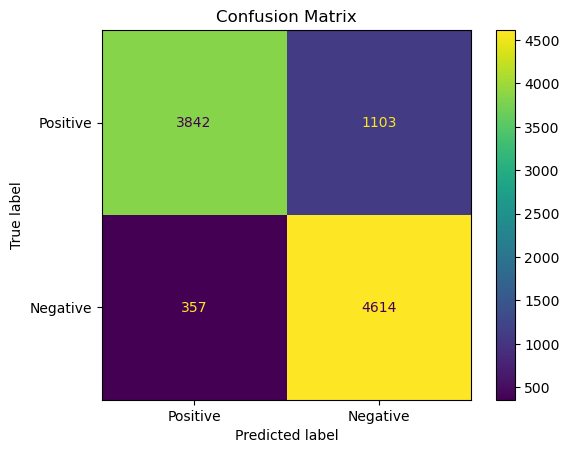

In [22]:
# confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred,display_labels=['Positive', 'Negative'])
plt.title('Confusion Matrix')
plt.show()

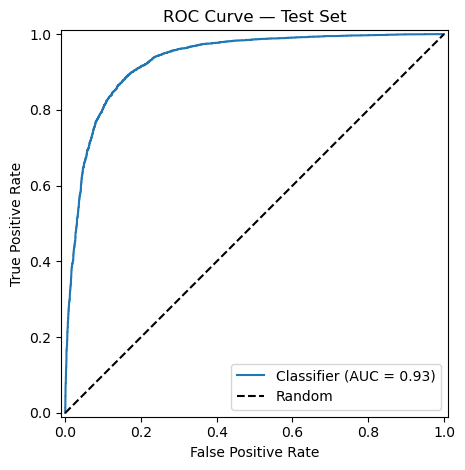

In [23]:
# ROC-AUC Performance Visualization
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.plot([0, 1], [0, 1],'k--', label='Random')
plt.title('ROC Curve — Test Set')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# sentiment Analysis

In [24]:
test_sentences = [
"This movie was absolutely fantastic. I loved every minute of it.",
"This was the worst movie I have ever watched.",
"An amazing film with brilliant acting and a wonderful story.",
"The story was boring and the acting was terrible.",
"The performances were outstanding and the ending was perfect."]


test_seq = tokenizer.texts_to_sequences(test_sentences)
pad_test = pad_sequences(test_seq)

prediction = model.predict(pad_test)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step


array([[0.91406757],
       [0.00166267],
       [0.99930346],
       [0.00284696],
       [0.9651234 ]], dtype=float32)

In [25]:
sentiment = []

for p in prediction:
    if p > 0.5:
        sentiment.append("Positive")
    else:
        sentiment.append("Negative")

print(sentiment)

['Positive', 'Negative', 'Positive', 'Negative', 'Positive']
